In [2]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa
from refractiveindex import RefractiveIndexMaterial

## We first compare the Drude parameters of the paper with the experimental values obtained from Johnson and Christy. It seems the paper is primarily interested in the region $0<\omega<\omega_p$, so this is the region on which we focus. 

In [6]:
omega_p = 7.9 # Bulk plasma frequency in eV
gamma_e = 0.09 # Drude electronic relaxation time in eV
hbar_c = 6.58211957 * 3 * 10 #200 # in nanometers * eV
lambda_min = 2*pi/(omega_p/hbar_c) * 1.2 # We'd like to go down to the plasma frequency but Johnson & Christy doesn't have data in that frequency range
lambda_max = 10 * lambda_min
Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Johnson')
#Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Werner-DFT')

wavelengths_nm = linspace(lambda_min, lambda_max, 301)  # [nm]
omegas_ev = hbar_c * (2*pi/wavelengths_nm)
gold_epsilon = Gold.get_epsilon(wavelengths_nm)
gold_epsilon_drude = 1 - omega_p**2/(omegas_ev*(omegas_ev + 1j*gamma_e))

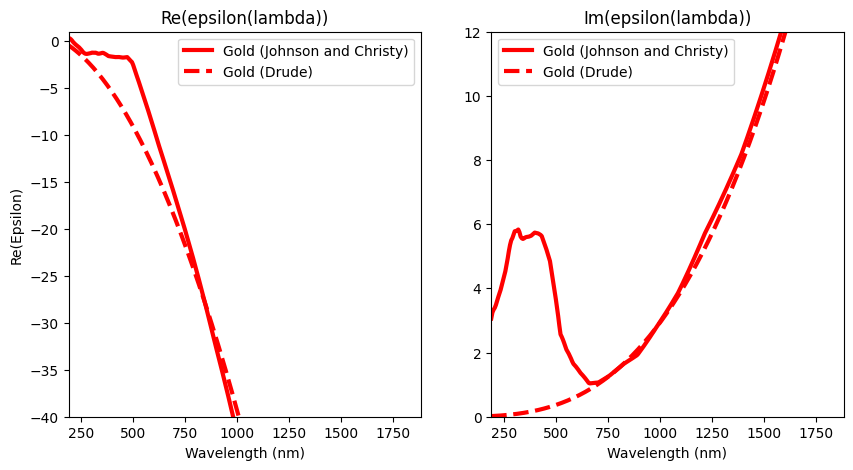

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(wavelengths_nm, gold_epsilon.real, color="red", label="Gold (Johnson and Christy)", linewidth=3)
ax1.plot(wavelengths_nm, gold_epsilon_drude.real, color="red", label="Gold (Drude)", linestyle="dashed", linewidth=3)

ax2.plot(wavelengths_nm, gold_epsilon.imag, color="red", label="Gold (Johnson and Christy)", linewidth=3)
ax2.plot(wavelengths_nm, gold_epsilon_drude.imag, color="red", label="Gold (Drude)", linestyle="dashed", linewidth=3)

ax1.set_xlim(lambda_min, lambda_max);
ax2.set_xlim(lambda_min, lambda_max);
ax1.set_title("Re(epsilon(lambda))")
ax2.set_title("Im(epsilon(lambda))")
ax1.legend();
ax2.legend();
ax1.set_xlabel("Wavelength (nm)")
ax2.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Re(Epsilon)");
ax1.set_ylim(-40, 1)
ax2.set_ylim(0, 12);

In [8]:
# We define the drude dielectric function, which takes in the ratio omega/omega_p
def gold_drude(omega_over_omega_p, omega_p=7.9, gamma_e=0.09):
    return 1-1/(omega_over_omega_p*(omega_over_omega_p+1j*gamma_e/omega_p))

In [ ]:
K = 100
N = 200
l = 1
Hs = [0.4, 0.8, 1.2] # list of values for H = a-b used in the paper
Rs = linspace(2, 7, K) # Range of Rs (normalized value of b) used in the paper
omega_over_omega_ps_real = linspace(0.01, 1, N) # range of real(omega)/omega_p
omega_over_omega_ps_imag = linspace(0.0001, 1, N) # range of imag(omega)/omega_p
omega_over_omega_ps = omega_over_omega_ps_real.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag.reshape((1, N)).repeat(N, axis=0)
gamma_e = 0
heatmap_data_v = [] # list of heatmaps, one for each value of H
gammas_v = []
for (H_indx, H) in enumerate(Hs):
    print("H: ", H)
    gammas = np.zeros((K, N))
    heatmap_data = np.zeros((K, N))
    for (R_idx, R) in enumerate(Rs):
        if (R_idx % 10) == 0:
            print(R_idx)
        epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
        kR = R * omega_over_omega_ps
        previous_coefficients = np.array([1, 1])
        
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
        
        epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
        kR =  (H+R) * omega_over_omega_ps
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        heatmap_data[R_idx, :] =  scattering_amplitudes.max(axis=1) # maximum across all imaginary values for the frequency
        gammas[R_idx, :] = omega_over_omega_ps_imag[scattering_amplitudes.argmax(axis=1)]

    heatmap_data_v.append(heatmap_data)
    gammas_v.append(gammas)

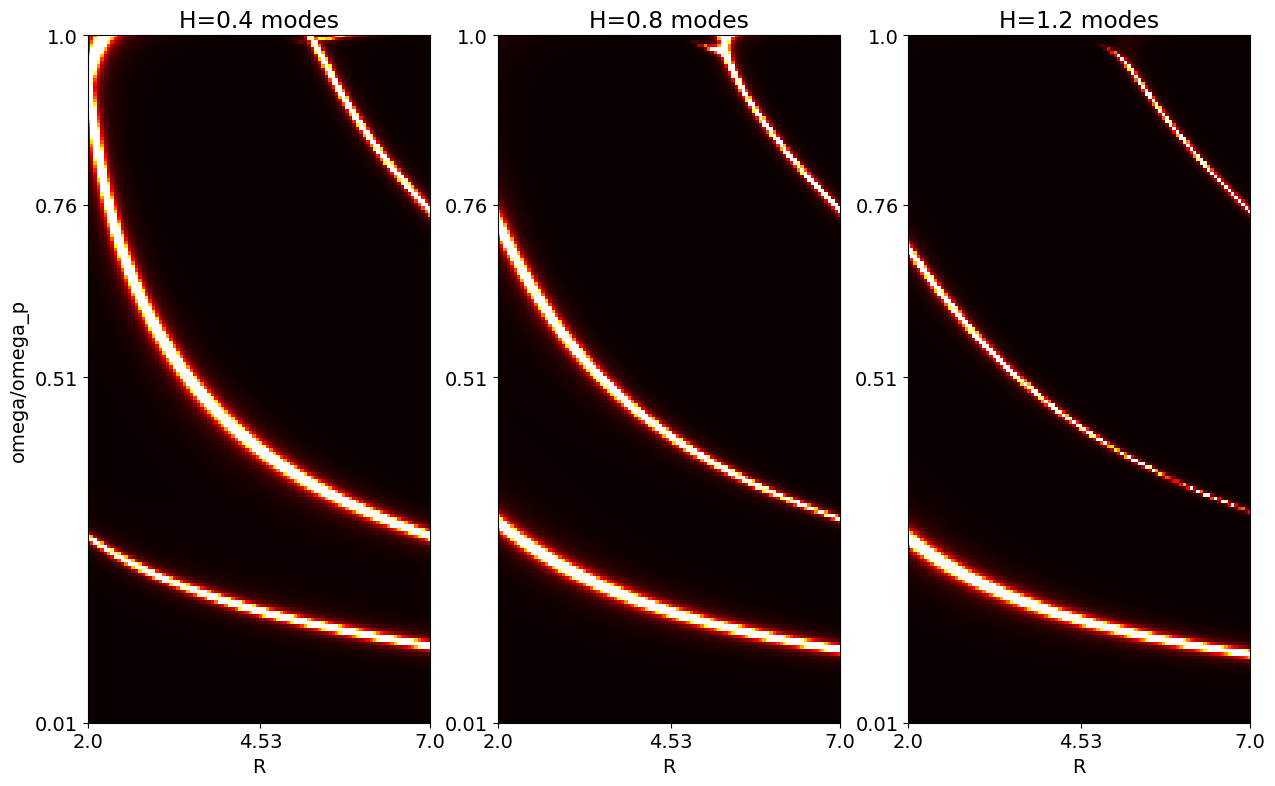

In [10]:
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,10))
for (ax_idx, ax) in enumerate([ax1, ax2, ax3]):
    heatmap_data = heatmap_data_v[ax_idx]
    H = Hs[ax_idx]
    ax.imshow(heatmap_data.T, cmap="hot", vmin=1, vmax=200, origin="lower");
    ax.set_xticks([0, K/2, K-1], Rs[[0, round(K/2), K-1]].round(2))
    ax.set_yticks([0, N/2, N*3/4, N-1], omega_over_omega_ps_real[[0, round(N/2), round(3*N/4), N-1]].round(2))
    ax.set_xlim(0, K-1)
    ax.set_ylim(0, N-1);
    ax.set_xlabel("R")
    if ax_idx == 0:
        ax.set_ylabel("omega/omega_p");
    ax.set_title(f"H={H} modes");

## We first focus on the sphere-like modes, by filtering out modes above $0.3\omega_p$

In [49]:
x_v = []; y_v = []
for heatmap_data in heatmap_data_v:
    x, y = np.where(heatmap_data > 20) # Find where the modes are 
    first_mode_idxs = np.where(omega_over_omega_ps_real[y] < 0.3) # Indices for the lowest mode
    x = x[first_mode_idxs]
    y = y[first_mode_idxs]
    filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
    x = x[filter_idxs]
    y = y[filter_idxs]
    x_v.append(x)
    y_v.append(y)

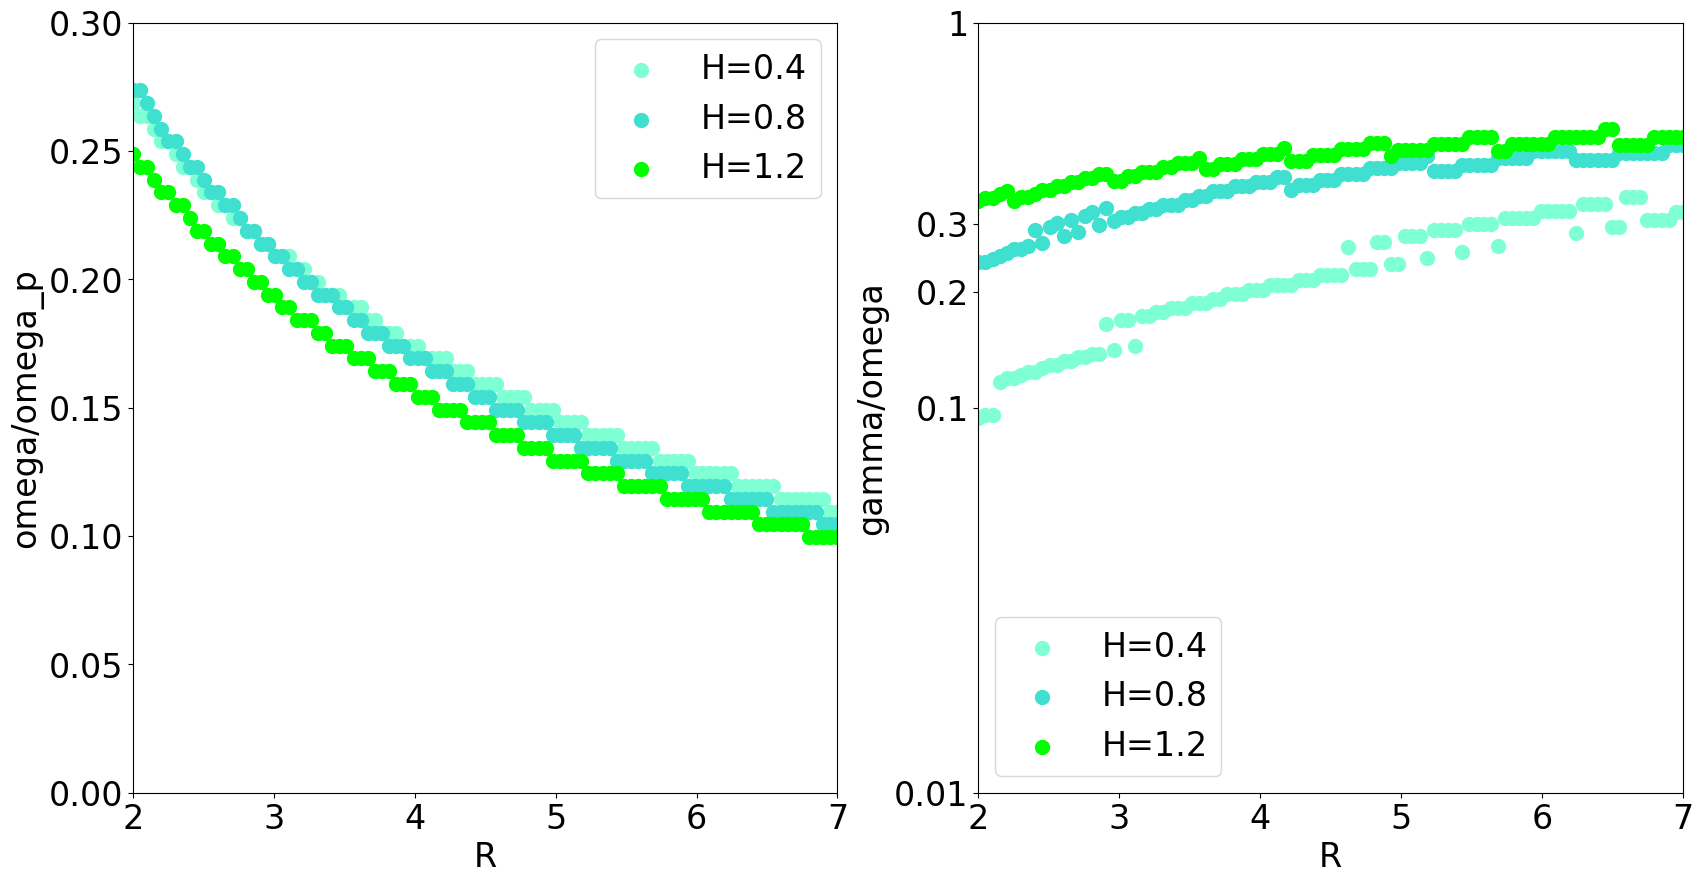

In [50]:
colors = ["aquamarine", "turquoise", "lime"]
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (H, color, x, y) in zip(Hs, colors, x_v, y_v):
    ax1.scatter(Rs[x], omega_over_omega_ps_real[y], color=color, s=100, label=f"H={H}");
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
ax1.legend();
ax1.set_ylim(0, 0.3);

for (H, color, x, y, gammas) in zip(Hs, colors, x_v, y_v, gammas_v):
    ax2.scatter(Rs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100, label=f"H={H}");
ax2.set_xlabel("R")
ax2.set_yticks([log(0.01), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(2, 7);
ax2.legend();
ax2.set_ylim(log(0.01), log(1));

## To make a smooth plot, we zoom in on the real and imaginary frequency ranges near the modes. The obtained plots should be close to the sphere-like modes plotted in Figure 1 of [Radiative decay of plasmons in a metallic nanoshell](https://link.aps.org/pdf/10.1103/PhysRevB.69.155402?casa_token=ysrofqx3MhMAAAAA:PO2xtgoR8T6w5glk_0FlmUHMIk5X6qtD1tdgkH6TqaDN3p0EXLMs_s-OFhfZkDREXNWQ3-83KUphDw).

In [ ]:
K = 100
N = 50
gamma_e = 0
optimized_gammas_v_sphere = []
optimized_omegas_v_sphere = []
optimized_Rs_v_sphere = []
for (H_idx, H) in enumerate(Hs):
    print("H = ", H);
    x = x_v[H_idx]; y = y_v[H_idx]; gammas = gammas_v[H_idx]
    optimized_gammas = np.zeros(Rs[x].shape[0])
    optimized_omegas = np.zeros(Rs[x].shape[0])
    optimized_Rs = np.zeros(Rs[x].shape[0])
    for idx in range(0, Rs[x].shape[0]):
        if (idx % 10) == 0: 
            print(idx)
        R = Rs[x[idx]]
        starting_omega = omega_over_omega_ps_real[y[idx]]
        starting_gamma = gammas[x[idx], y[idx]]
    
        omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
        omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
        omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)
    
        epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
        kR = R * omega_over_omega_ps
        previous_coefficients = np.array([1, 1])
        
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
        
        epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
        kR =  (H+R) * omega_over_omega_ps
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        max_idx = scattering_amplitudes.argmax()
        row, col = unravel_index(max_idx, (N, N))
        optimized_Rs[idx] = R
        optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
        optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]
    optimized_gammas_v_sphere.append(optimized_gammas)
    optimized_omegas_v_sphere.append(optimized_omegas)
    optimized_Rs_v_sphere.append(optimized_Rs)


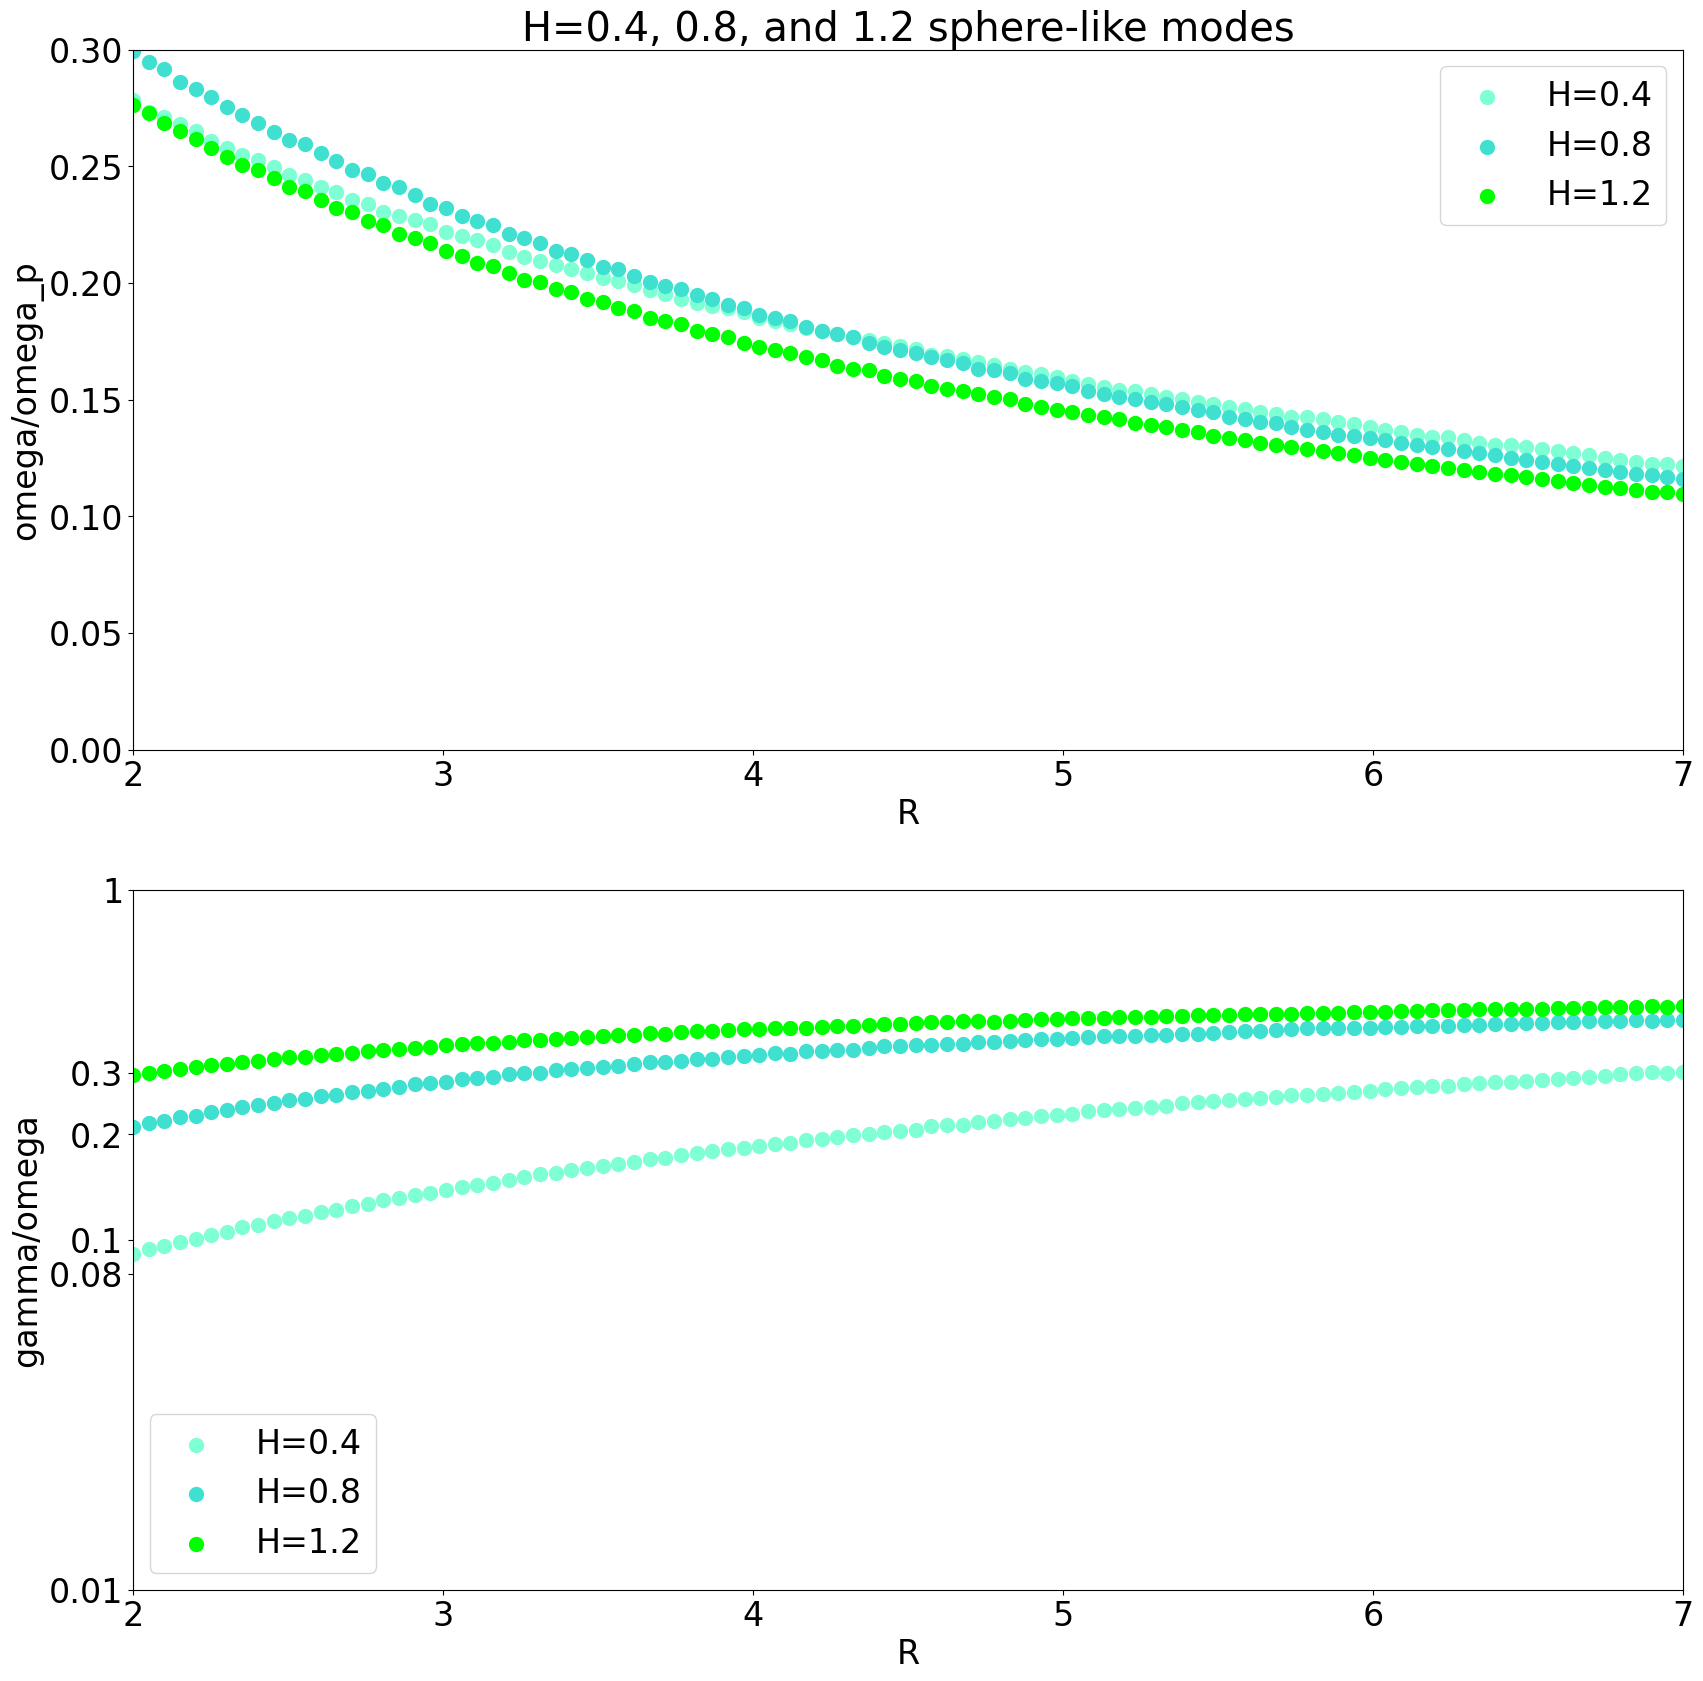

In [52]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
for (H, color, optimized_Rs, optimized_omegas, optimized_gammas) in zip(Hs, colors, optimized_Rs_v_sphere, optimized_omegas_v_sphere, optimized_gammas_v_sphere):
    ax1.scatter(optimized_Rs, optimized_omegas, s=100, color=color, label=f"H={H}")
    ax2.scatter(optimized_Rs, log(optimized_gammas/optimized_omegas), s=100, color=color, label=f"H={H}")

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
ax1.set_ylim(0, 0.3);
ax1.legend();
ax2.set_yticks([log(0.01), log(0.08), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.08, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("R")
ax2.set_xlim(2, 7);
ax2.set_ylim(log(0.01), log(1));
ax2.legend();
ax1.set_title("H=0.4, 0.8, and 1.2 sphere-like modes");

## Now we turn to the void-like modes

In [54]:
x_v = []; y_v = []
for (optimized_omegas, heatmap_data) in zip(optimized_omegas_v_sphere, heatmap_data_v):
    x, y = np.where(heatmap_data > 20) # Find where the modes are 
    first_mode_idxs = np.where(omega_over_omega_ps_real[y] > 1.5*optimized_omegas[x]) # Indices for the lowest mode
    x = x[first_mode_idxs]
    y = y[first_mode_idxs]
    filter_idxs = np.array([np.where(x==i)[0][0] for i in range(0, 100)])
    x = x[filter_idxs]
    y = y[filter_idxs]
    x_v.append(x)
    y_v.append(y)

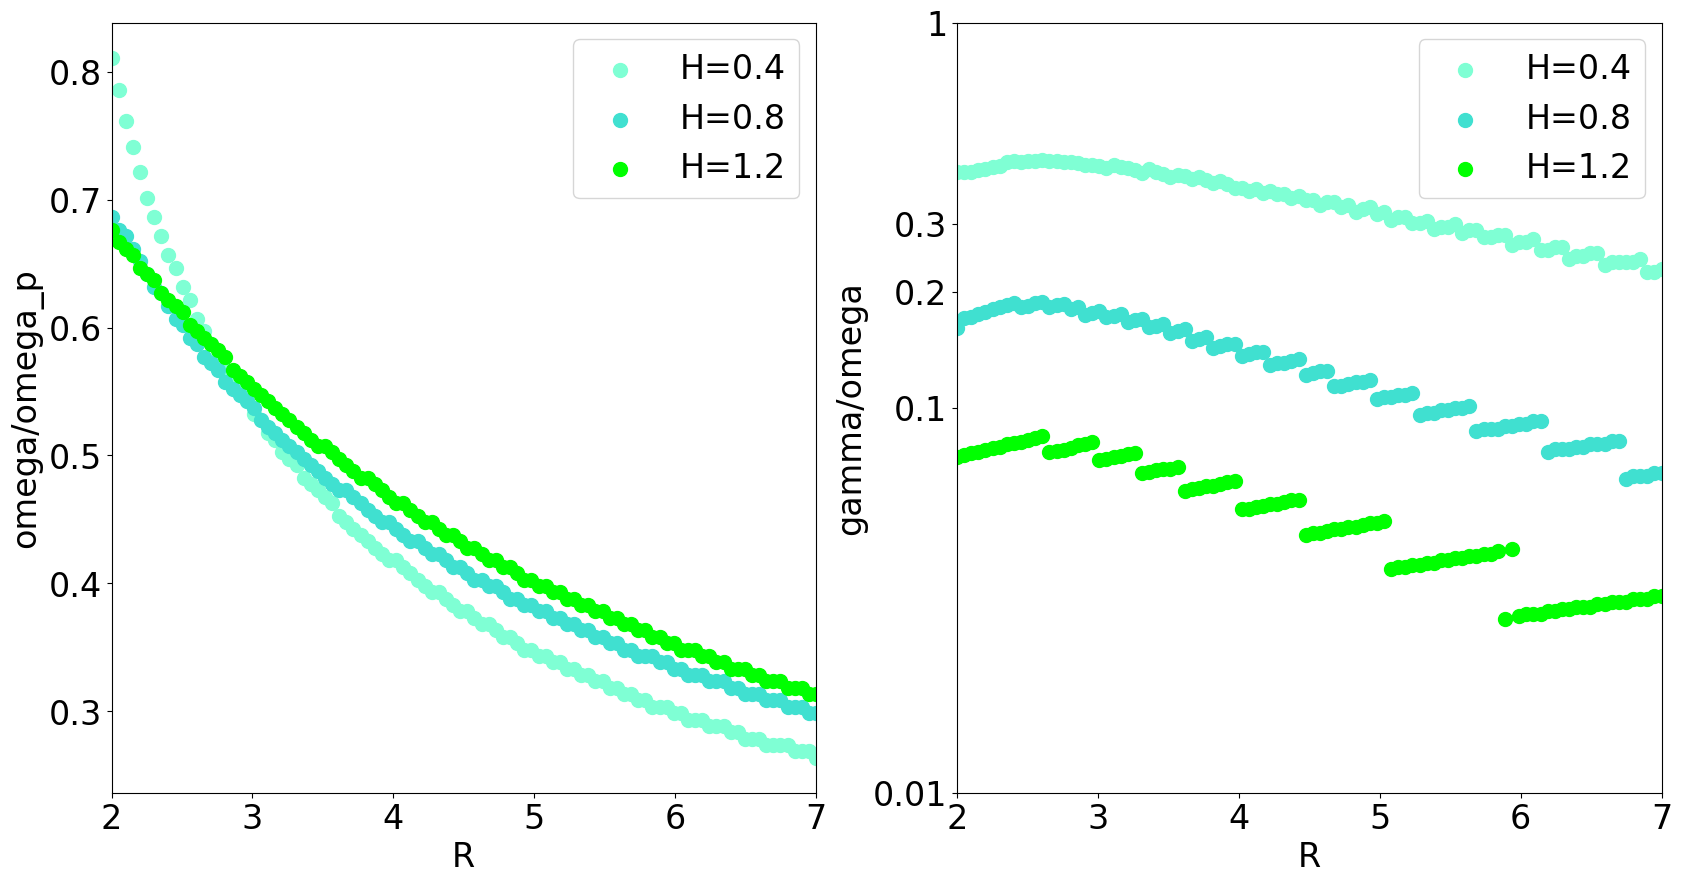

In [55]:
colors = ["aquamarine", "turquoise", "lime"]
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (H, color, x, y) in zip(Hs, colors, x_v, y_v):
    ax1.scatter(Rs[x], omega_over_omega_ps_real[y], color=color, s=100, label=f"H={H}");
ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
ax1.legend();

for (H, color, x, y, gammas) in zip(Hs, colors, x_v, y_v, gammas_v):
    ax2.scatter(Rs[x], log(gammas[x, y]/omega_over_omega_ps_real[y]), color=color, s=100, label=f"H={H}");
ax2.set_xlabel("R")
ax2.set_yticks([log(0.01), log(0.1), log(0.2), log(0.3), log(1)], [0.01, 0.1, 0.2, 0.3, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlim(2, 7);
ax2.legend();
ax2.set_ylim(log(0.01), log(1));

In [ ]:
K = 100
N = 50
gamma_e = 0
optimized_gammas_v_void = []
optimized_omegas_v_void = []
optimized_Rs_v_void = []
for (H_idx, H) in enumerate(Hs):
    print("H = ", H);
    x = x_v[H_idx]; y = y_v[H_idx]; gammas = gammas_v[H_idx]
    optimized_gammas = np.zeros(Rs[x].shape[0])
    optimized_omegas = np.zeros(Rs[x].shape[0])
    optimized_Rs = np.zeros(Rs[x].shape[0])
    for idx in range(0, Rs[x].shape[0]):
        if (idx % 25) == 0: 
            print(idx)
        R = Rs[x[idx]]
        starting_omega = omega_over_omega_ps_real[y[idx]]
        starting_gamma = gammas[x[idx], y[idx]]
    
        omega_over_omega_ps_real_zoom = linspace(0.8, 1.2, N) * starting_omega 
        omega_over_omega_ps_imag_zoom = linspace(0.8, 1.2, N) * starting_gamma
        omega_over_omega_ps = omega_over_omega_ps_real_zoom.reshape((N, 1)).repeat(N, axis=1) - 1j*omega_over_omega_ps_imag_zoom.reshape((1, N)).repeat(N, axis=0)
    
        epsilon2 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); epsilon1 =  ones((N, N))
        kR = R * omega_over_omega_ps
        previous_coefficients = np.array([1, 1])
        
        next_coefficients = e_r_recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
        
        epsilon2 = ones((N, N)) ; epsilon1 = gold_drude(omega_over_omega_ps, gamma_e=gamma_e); 
        kR =  (H+R) * omega_over_omega_ps
        next_coefficients = e_r_recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
        
        scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
        max_idx = scattering_amplitudes.argmax()
        row, col = unravel_index(max_idx, (N, N))
        optimized_Rs[idx] = R
        optimized_omegas[idx] = omega_over_omega_ps_real_zoom[row]
        optimized_gammas[idx] = omega_over_omega_ps_imag_zoom[col]
    optimized_gammas_v_void.append(optimized_gammas)
    optimized_omegas_v_void.append(optimized_omegas)
    optimized_Rs_v_void.append(optimized_Rs)

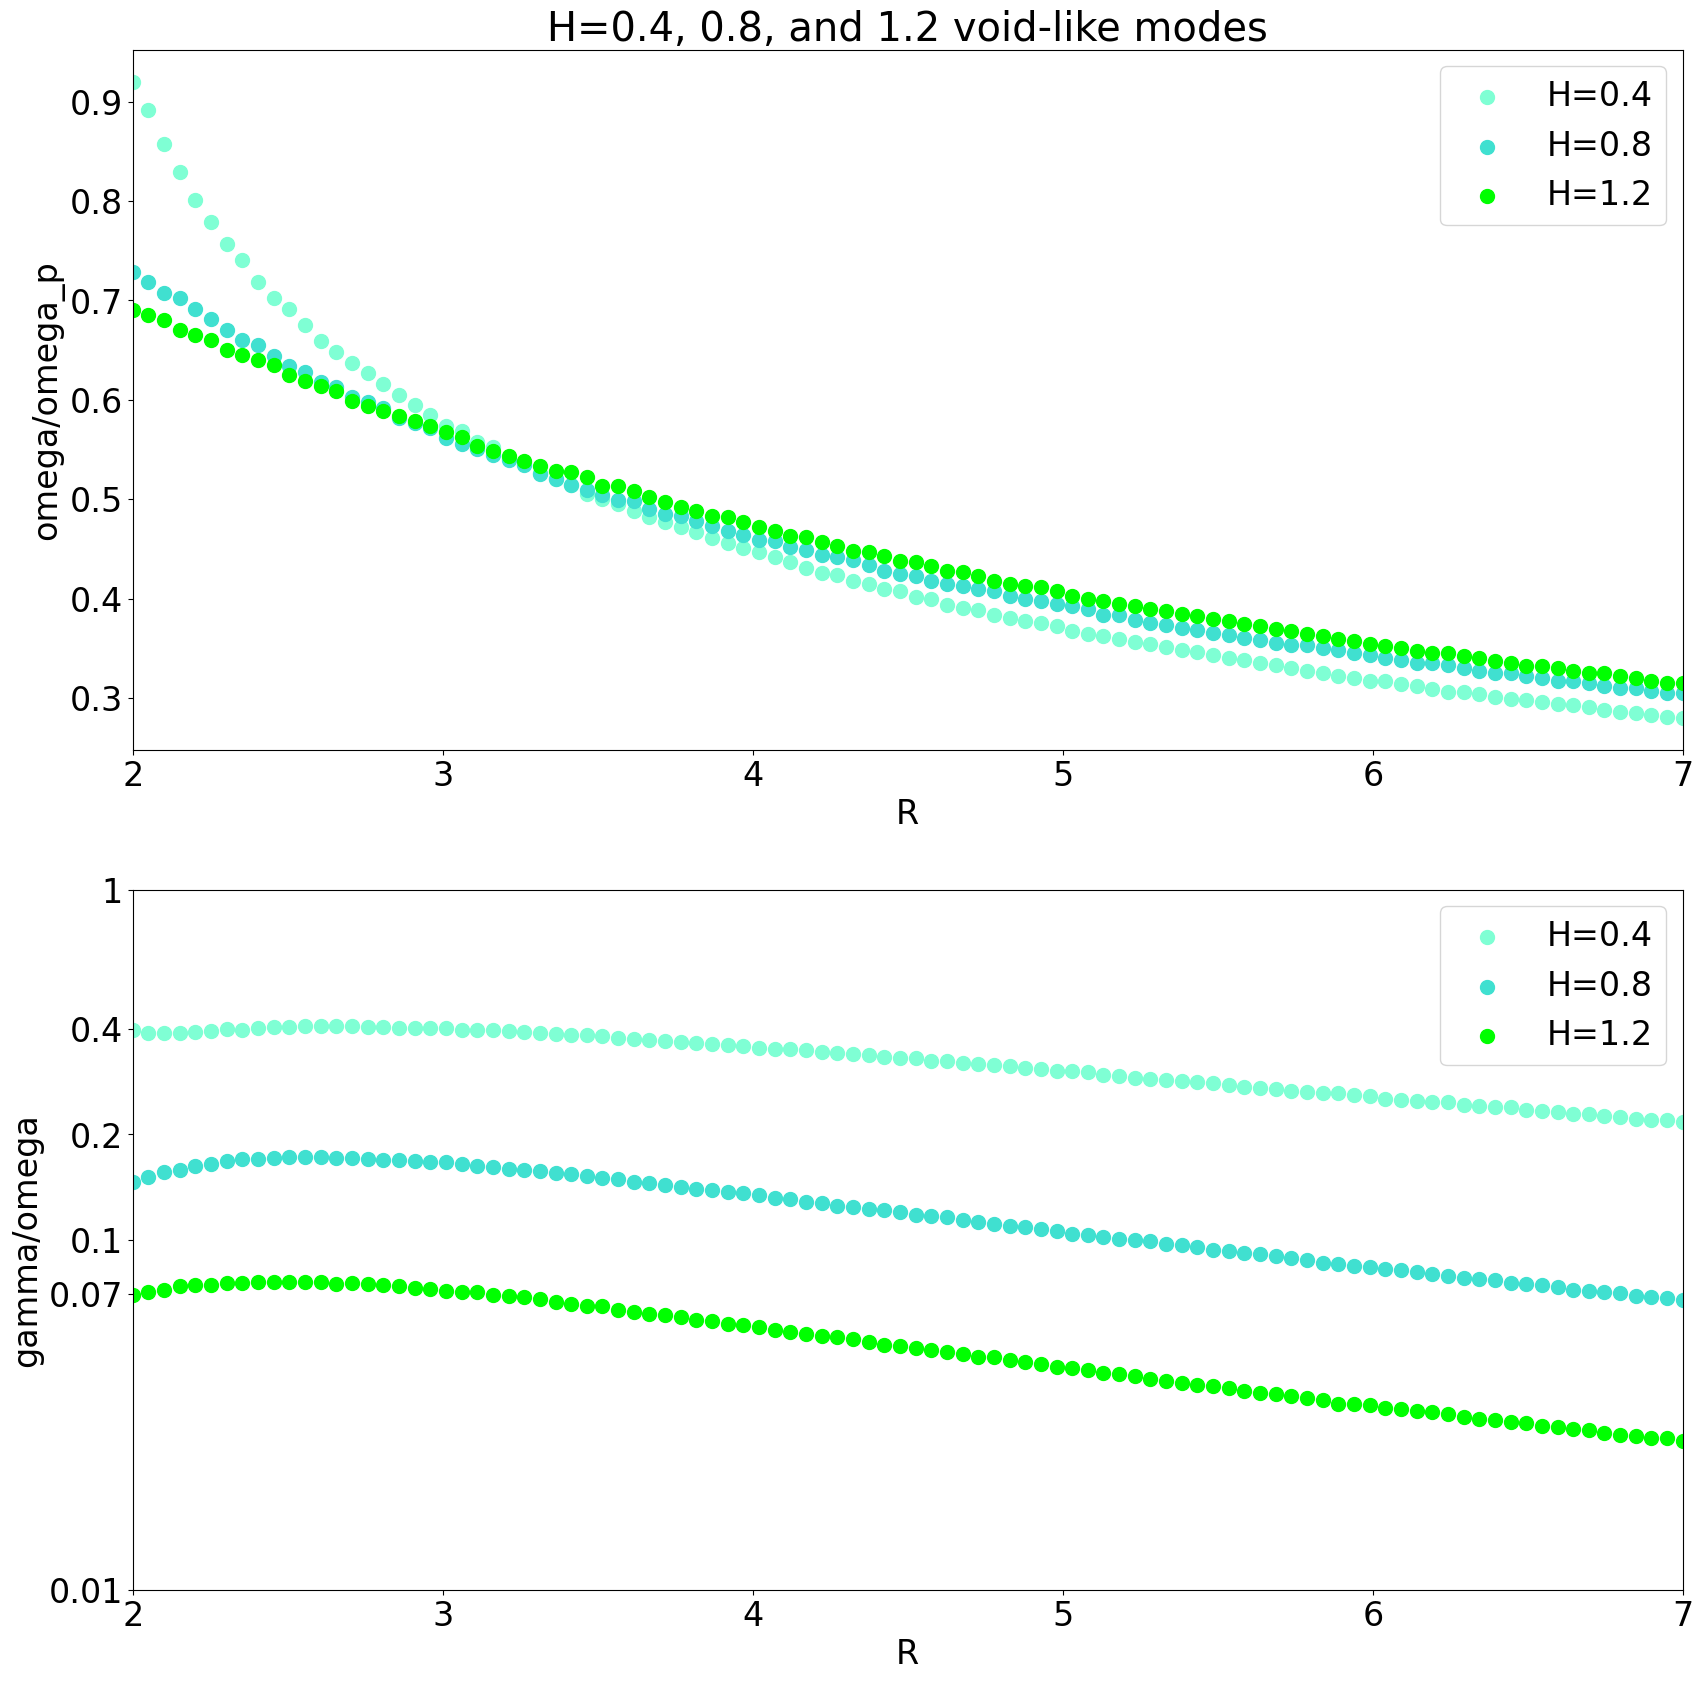

In [58]:
plt.rcParams.update({'font.size': 24})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))
for (H, color, optimized_Rs, optimized_omegas, optimized_gammas) in zip(Hs, colors, optimized_Rs_v_void, optimized_omegas_v_void, optimized_gammas_v_void):
    ax1.scatter(optimized_Rs, optimized_omegas, s=100, color=color, label=f"H={H}")
    ax2.scatter(optimized_Rs, log(optimized_gammas/optimized_omegas), s=100, color=color, label=f"H={H}")

ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
#ax1.set_ylim(0, 0.3);
ax1.legend();
ax2.set_yticks([log(0.01), log(0.07), log(0.1), log(0.2), log(0.4), log(1)], [0.01, 0.07, 0.1, 0.2, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("R")
ax2.set_xlim(2, 7);
ax2.set_ylim(log(0.01), log(1));
ax2.legend();
ax1.set_title("H=0.4, 0.8, and 1.2 void-like modes");

## Plot everything as in Figure 1

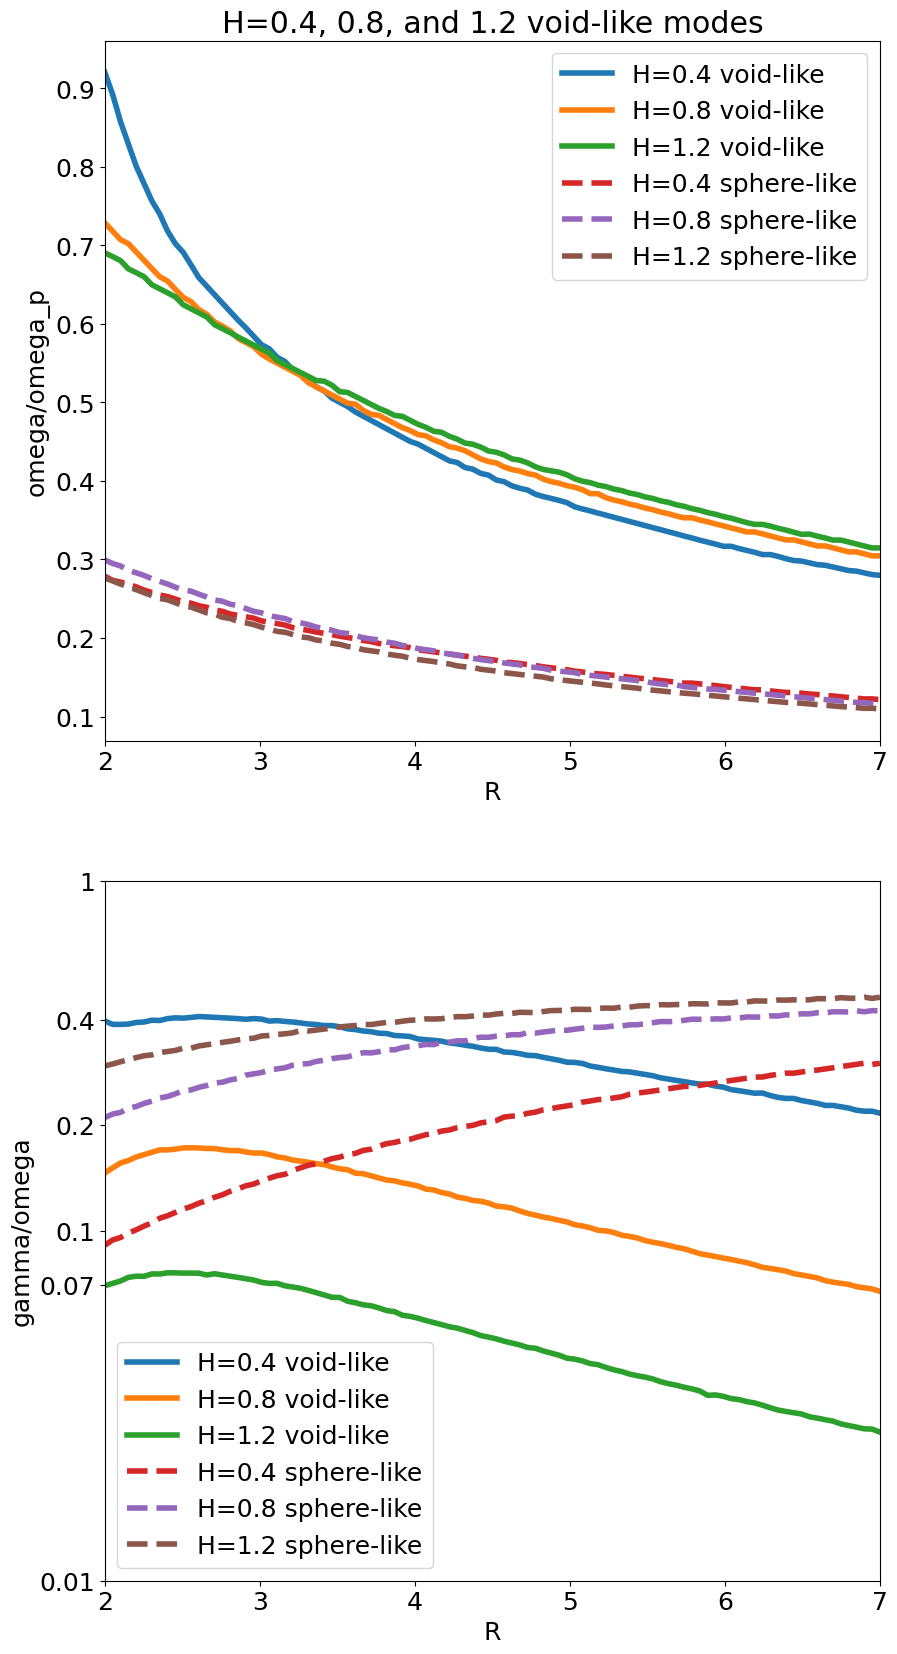

In [68]:
plt.rcParams.update({'font.size': 18})
linewidth=4
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))
for (H, color, optimized_Rs, optimized_omegas, optimized_gammas) in zip(Hs, colors, optimized_Rs_v_void, optimized_omegas_v_void, optimized_gammas_v_void):
    ax1.plot(optimized_Rs, optimized_omegas, label=f"H={H} void-like", linewidth=linewidth)
    ax2.plot(optimized_Rs, log(optimized_gammas/optimized_omegas), label=f"H={H} void-like", linewidth=linewidth)

for (H, color, optimized_Rs, optimized_omegas, optimized_gammas) in zip(Hs, colors, optimized_Rs_v_sphere, optimized_omegas_v_sphere, optimized_gammas_v_sphere):
    ax1.plot(optimized_Rs, optimized_omegas, label=f"H={H} sphere-like", linestyle="dashed", linewidth=linewidth)
    ax2.plot(optimized_Rs, log(optimized_gammas/optimized_omegas), label=f"H={H} sphere-like", linestyle="dashed", linewidth=linewidth)


ax1.set_xlabel("R")
ax1.set_ylabel("omega/omega_p");
ax1.set_xlim(2, 7);
#ax1.set_ylim(0, 0.3);
ax1.legend();
ax2.set_yticks([log(0.01), log(0.07), log(0.1), log(0.2), log(0.4), log(1)], [0.01, 0.07, 0.1, 0.2, 0.4, 1])
ax2.set_ylabel("gamma/omega");
ax2.set_xlabel("R")
ax2.set_xlim(2, 7);
ax2.set_ylim(log(0.01), log(1));
ax2.legend();
ax1.set_title("H=0.4, 0.8, and 1.2 void-like modes");